In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from category_encoders import BinaryEncoder, TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [82]:
data_train = pd.read_csv('data/train.csv')
data_gender = pd.read_csv('data/gender_submission.csv')
data_test = pd.read_csv('data/test.csv')

my_train_dataset = data_train.drop(columns=['Name','Ticket','Embarked','Cabin'])
my_train_dataset['Sex'] =  pd.factorize(my_train_dataset['Sex'])[0]
my_train_dataset = my_train_dataset[my_train_dataset['Age']<75]
my_train_dataset = my_train_dataset[my_train_dataset['Fare']<400]


my_train_dataset['Fare'] = pd.cut(my_train_dataset['Fare'], bins=[0, 40, 100, 200,300], labels=[0, 1, 2,3], right=True)

survival_by_fare_group = my_train_dataset.groupby('Fare')['Survived'].agg(['mean', 'count'])
survival_by_fare_group['mean']=survival_by_fare_group['mean']*100

SibSp = my_train_dataset.groupby('SibSp')['Survived'].agg(['mean', 'count'])
SibSp['mean']=SibSp['mean']*100

prop = my_train_dataset[my_train_dataset['Fare'].isna()]

my_train_dataset =my_train_dataset.dropna()
my_train_dataset =pd.merge(my_train_dataset, survival_by_fare_group, on='Fare')
my_train_dataset['Fare_fighting_chance'] = my_train_dataset['mean']
my_train_dataset = my_train_dataset.drop(columns=['mean','count','Fare'])

my_train_dataset =pd.merge(my_train_dataset, SibSp, on='SibSp')
my_train_dataset['SibSp_chance'] = my_train_dataset['mean']
my_train_dataset = my_train_dataset.drop(columns=['mean','count','SibSp'])



In [85]:
print(my_train_dataset.head())
print(my_train_dataset.isna().any())
print(survival_by_fare_group)
print(prop)
print(data_test)

   PassengerId  Survived  Pclass  Sex   Age  Parch  Fare_fighting_chance  \
0            1         0       3    0  22.0      0             33.574007   
1            2         1       1    1  38.0      0             63.461538   
2            3         1       3    1  26.0      0             33.574007   
3            4         1       1    1  35.0      0             63.461538   
4            5         0       3    0  35.0      0             33.574007   

   SibSp_chance  
0     53.005464  
1     53.005464  
2     36.616702  
3     53.005464  
4     36.616702  
PassengerId             False
Survived                False
Pclass                  False
Sex                     False
Age                     False
Parch                   False
Fare_fighting_chance    False
SibSp_chance            False
dtype: bool
           mean  count
Fare                  
0     33.574007    554
1     63.461538    104
2     73.333333     30
3     73.333333     15
     PassengerId  Survived  Pclass  Sex   Age

<Axes: xlabel='Fare_fighting_chance', ylabel='Count'>

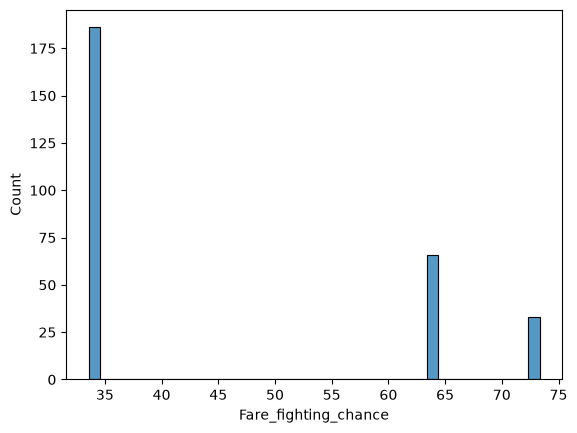

In [75]:
sns.histplot(my_train_dataset[my_train_dataset['Survived']==1]['Fare_fighting_chance'],binwidth=1)

<Axes: xlabel='Fare'>

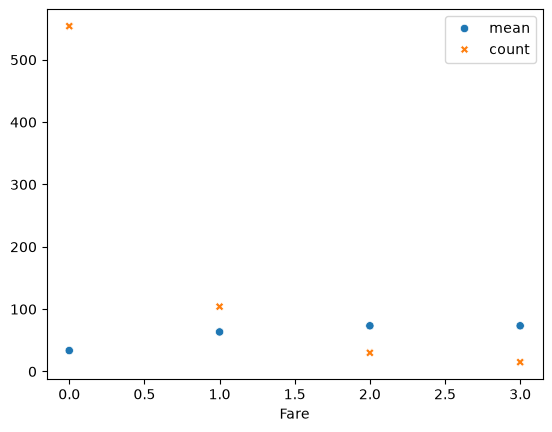

In [59]:
sns.scatterplot(data=survival_by_fare_group)

<Axes: xlabel='Fare_fighting_chance', ylabel='Age'>

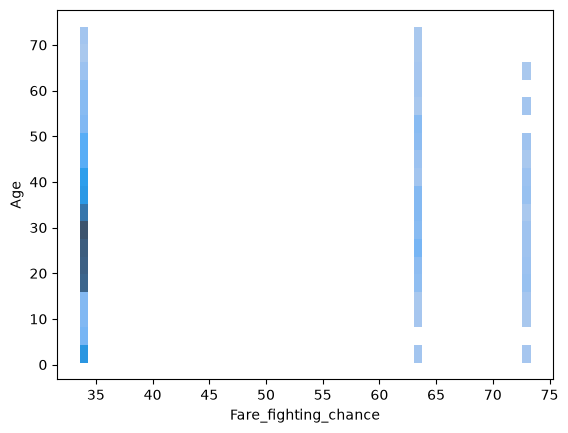

In [74]:
sns.histplot(data=my_train_dataset, x='Fare_fighting_chance', y='Age')

<Axes: xlabel='Pclass', ylabel='Count'>

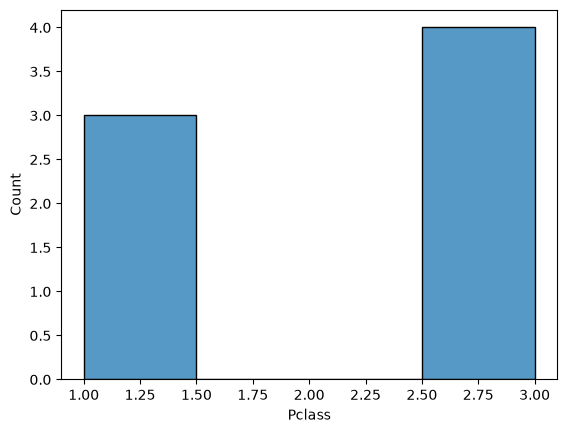

In [62]:
sns.histplot(prop['Pclass'])

<Axes: xlabel='SibSp', ylabel='Count'>

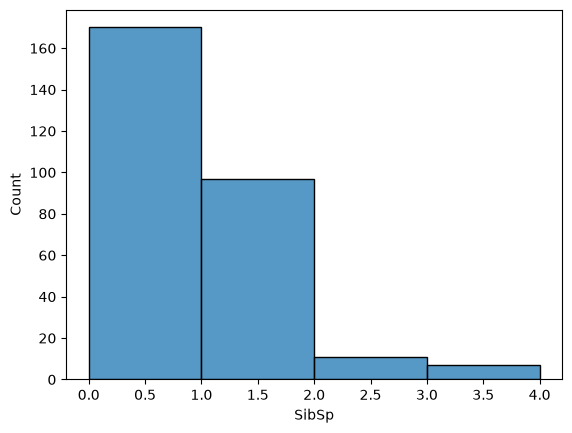

In [76]:
sns.histplot(my_train_dataset[my_train_dataset['Survived']==1]['SibSp'],binwidth=1)

<Axes: xlabel='SibSp'>

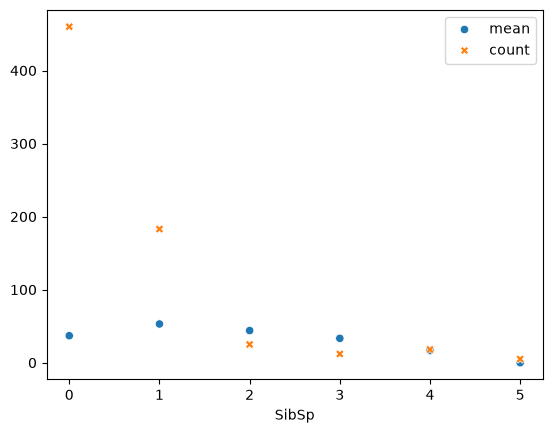

In [79]:
SibSp = my_train_dataset.groupby('SibSp')['Survived'].agg(['mean', 'count'])
SibSp['mean']=SibSp['mean']*100
sns.scatterplot(data=SibSp)

In [86]:
X_train = my_train_dataset.drop(columns=['Survived'])
y_train = my_train_dataset['Survived']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


#X_test_scaled = scaler.transform(X_test)


In [87]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [90]:
print(accuracy_score(y_train, model.predict(X_train_scaled)))

0.8008534850640113
